# QC Multiclass 0.5 Classifier

**Goal:** 7-class photo quality classifier that identifies WHY a photo is bad.

**Classes:**
- **good** — Clear, readable data label photo
- **blurry** — Camera shake or out of focus
- **too_dark** — Underexposed, label unreadable
- **glare** — Reflection washing out the label
- **low_text_legibility** — Label is faded, damaged, ink smeared, or rubbed out
- **qr_code** — Tech photographed a QR code instead of the data label
- **obstructed** — Something is physically blocking the label (hose, hand, wire, object)

**Architecture:** MobileNetV2 with transfer learning

**Output:** 7-class softmax — confidence score per class
```
{ good: 0.81, blurry: 0.03, too_dark: 0.02, glare: 0.02,
  low_text_legibility: 0.02, qr_code: 0.05, obstructed: 0.05 }
→ Prediction: good
```

**Exports:**
- `qc_multiclass.keras`
- `qc_multiclass.tflite`
- `model_metadata.json`

---
**Data folder structure expected inside zip:**
```
qc_multiclass_0.5/
  good/
  blurry/
  too_dark/
  glare/
  low_text_legibility/
  qr_code/
  obstructed/
```

**Minimum recommended images per class: 150-200**

**Run in Google Colab with GPU enabled:**
Runtime → Change runtime type → GPU

## 1. Setup & Upload Data

In [1]:
import os
import json
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.19.0
GPU available: False


In [2]:
# ==========================================
# DEPRECATED — replaced by cell below
# ==========================================

In [4]:
import os
import zipfile
from google.colab import drive

# ==========================================
# Mount Drive
# ==========================================
drive.mount('/content/drive')

# ==========================================
# Paths — update ZIP_NAME if your file is named differently
# ==========================================
ZIP_NAME    = "qc_multiclass_0.5.zip"
zip_path    = f"/content/drive/MyDrive/{ZIP_NAME}"
extract_path = "training_data"

if not os.path.exists(zip_path):
    raise FileNotFoundError(
        f"Zip not found at: {zip_path}\n"
        f"  Check your Google Drive — is the file named exactly '{ZIP_NAME}'?"
    )

# ==========================================
# Extract (only if not already extracted)
# ==========================================
if not os.path.exists(extract_path):
    print(f"Extracting {ZIP_NAME}...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print("Extraction complete.\n")
else:
    print("Dataset already extracted.\n")

# ==========================================
# Class definitions
# ==========================================
CLASSES = [
    'good', 'blurry', 'too_dark', 'glare',
    'low_text_legibility', 'qr_code', 'obstructed'
]

# ==========================================
# Auto-detect data directory
# Covers: zip contained a root folder, or class folders are at the root
# ==========================================
candidates = [
    f'training_data/qc_multiclass_0.5',   # zip included root folder
    f'training_data/qc_multiclass-0.5',   # hyphen variant
    'training_data/photos',               # photos/ subfolder
    'training_data',                      # class folders at root of zip
]

for candidate in candidates:
    if os.path.isdir(candidate) and all(
        os.path.isdir(os.path.join(candidate, c)) for c in CLASSES
    ):
        DATA_DIR = candidate
        break
else:
    print("Could not find class folders. Extracted structure:")
    for root, dirs, _ in os.walk('training_data'):
        level = root.replace('training_data', '').count(os.sep)
        if level < 3:
            for d in dirs:
                print("  " * level + os.path.join(root, d))
    raise FileNotFoundError(
        f"Expected folders: {CLASSES}\n"
        f"Check the structure printed above and update candidates list."
    )

print(f"Data directory found: {DATA_DIR}\n")

# ==========================================
# Count per class
# ==========================================
class_counts = {}
total = 0

for cls in CLASSES:
    cls_path = os.path.join(DATA_DIR, cls)
    count = len([
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    class_counts[cls] = count
    total += count
    print(f"  {cls:<22}: {count:>4} images")

print(f"  {'TOTAL':<22}: {total:>4} images")

# ==========================================
# Warn if under-represented
# ==========================================
MIN_RECOMMENDED = 150
print()
for cls, count in class_counts.items():
    if count < MIN_RECOMMENDED:
        print(f"  WARNING: {cls} only has {count} images (recommended: {MIN_RECOMMENDED}+)")

# ==========================================
# Class weights (match Keras alphabetical order)
# ==========================================
num_classes  = len(CLASSES)
sorted_classes = sorted(CLASSES)

class_weights = {
    i: total / (num_classes * class_counts[cls])
    for i, cls in enumerate(sorted_classes)
}

print("\nClass weights (alphabetical order — matches Keras):")
for i, cls in enumerate(sorted_classes):
    print(f"  {i} ({cls}): {class_weights[i]:.3f}")

Mounted at /content/drive
Extracting qc_multiclass_0.5.zip...
Extraction complete.

Data directory found: training_data/qc_multiclass_0.5

  good                  :  440 images
  blurry                :  111 images
  too_dark              :  113 images
  glare                 :  133 images
  low_text_legibility   :  198 images
  qr_code               :  184 images
  obstructed            :  247 images
  TOTAL                 : 1426 images


Class weights (alphabetical order — matches Keras):
  0 (blurry): 1.835
  1 (glare): 1.532
  2 (good): 0.463
  3 (low_text_legibility): 1.029
  4 (obstructed): 0.825
  5 (qr_code): 1.107
  6 (too_dark): 1.803


## 2. Data Loading & Augmentation

In [5]:
# Configuration
IMG_SIZE = 224
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
SEED = 42
NUM_CLASSES = 7  # blurry, glare, good, low_text_legibility,
                 # obstructed, qr_code, too_dark

In [6]:
# Load datasets
# label_mode='categorical' gives one-hot encoded labels for multi-class softmax
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
)

val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
)

class_names = train_ds.class_names  # alphabetical order
print(f"Class order (alphabetical): {class_names}")
print("Note: This is the index order the model uses for predictions")

Found 1426 files belonging to 7 classes.
Using 1141 files for training.
Found 1426 files belonging to 7 classes.
Using 285 files for validation.
Class order (alphabetical): ['blurry', 'glare', 'good', 'low_text_legibility', 'obstructed', 'qr_code', 'too_dark']
Note: This is the index order the model uses for predictions


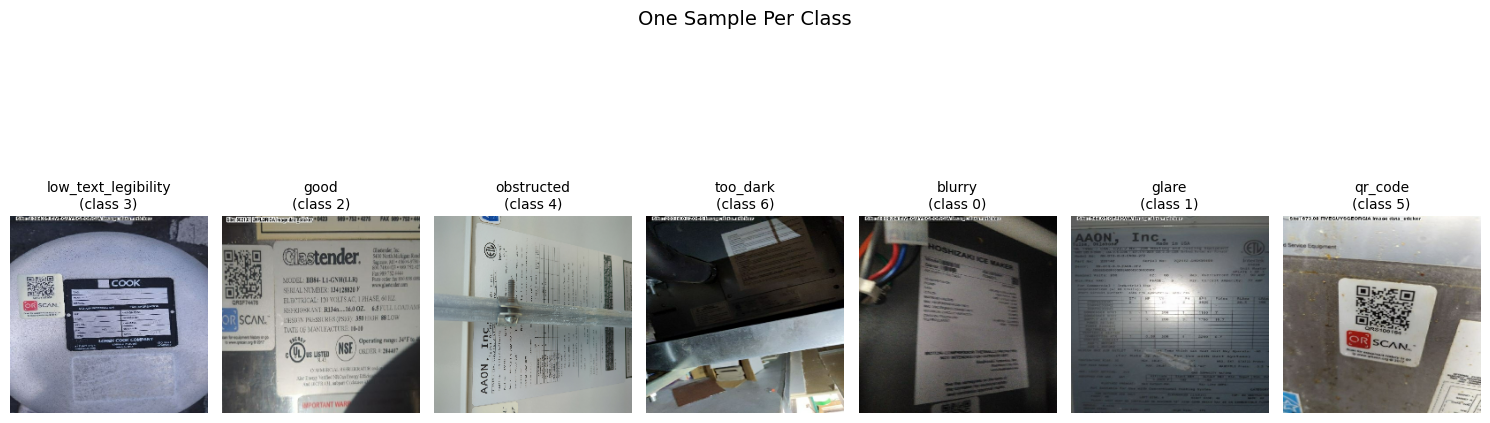

In [7]:
# Preview sample images per class
plt.figure(figsize=(15, 6))
for images, labels in train_ds.take(1):
    shown = {}
    for i in range(len(images)):
        cls_idx = int(np.argmax(labels[i].numpy()))
        cls_name = class_names[cls_idx]
        if cls_name not in shown and len(shown) < NUM_CLASSES:
            shown[cls_name] = (images[i], cls_idx)
        if len(shown) == NUM_CLASSES:
            break
    for j, (cls_name, (img, idx)) in enumerate(shown.items()):
        ax = plt.subplot(1, NUM_CLASSES, j + 1)
        plt.imshow(img.numpy().astype('uint8'))
        plt.title(f"{cls_name}\n(class {idx})", fontsize=10)
        plt.axis('off')
plt.suptitle('One Sample Per Class', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Data augmentation — same as Gatekeeper_0.5
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
], name='data_augmentation')

# Performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Augmentation and prefetch configured.")

Augmentation and prefetch configured.


## 3. Build Model (MobileNetV2 + 7-Class Softmax)

In [9]:
# Load pre-trained MobileNetV2 — same base as Gatekeeper_0.5
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
)
base_model.trainable = False

print(f"Base model layers: {len(base_model.layers)}")
print(f"Base model params: {base_model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers: 154
Base model params: 2,257,984


In [10]:
# Build the full model
# Key difference from binary: output is Dense(7, softmax) instead of Dense(1, sigmoid)
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)

# 7-class softmax output — one confidence score per class
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='defect_class')(x)

model = keras.Model(inputs, outputs, name='photo_defect_classifier')
model.summary()

Model: "photo_defect_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ defect_class (Dense)            │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4. Compile Model

In [11]:
# categorical_crossentropy for multi-class (one-hot labels)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

print("Model compiled with categorical_crossentropy loss (multi-class)")

Model compiled with categorical_crossentropy loss (multi-class)


## 5. Phase 1: Train Classification Head (Frozen Base)

In [12]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print("=== Phase 1: Training classification head (base frozen) ===")
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights,
)

phase1_epochs = len(history_phase1.history['loss'])
print(f"Phase 1 completed in {phase1_epochs} epochs")

=== Phase 1: Training classification head (base frozen) ===
Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.2988 - loss: 2.0436 - precision: 0.4197 - recall: 0.1157 - val_accuracy: 0.6105 - val_loss: 1.2145 - val_precision: 0.8073 - val_recall: 0.3088 - learning_rate: 0.0010
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.5548 - loss: 1.2628 - precision: 0.7158 - recall: 0.4058 - val_accuracy: 0.6281 - val_loss: 1.1034 - val_precision: 0.7965 - val_recall: 0.4807 - learning_rate: 0.0010
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.6167 - loss: 1.1923 - precision: 0.7434 - recall: 0.4604 - val_accuracy: 0.6842 - val_loss: 1.0241 - val_precision: 0.8687 - val_recall: 0.4877 - learning_rate: 0.0010
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.6408 - loss: 1.1129 - precision: 0.7970 - recall: 0.5132 - val_accuracy: 0.6596 - val_loss: 1.0667 - val_precision: 0.8228 - val_recall: 0.4561 - learning_rate: 0.0010
Epoch 5/10


## 6. Phase 2: Fine-tune (Unfreeze Top Layers)

In [13]:
base_model.trainable = True

# Freeze early layers, fine-tune top layers
for layer in base_model.layers[:100]:
    layer.trainable = False

trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
print(f"Fine-tuning {trainable_count} layers (out of {len(base_model.layers)})")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')],
)

print("\n=== Phase 2: Fine-tuning top layers ===")
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    initial_epoch=phase1_epochs,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights,
)

phase2_epochs = len(history_phase2.history['loss'])
print(f"Phase 2 completed in {phase2_epochs} epochs")

Fine-tuning 54 layers (out of 154)

=== Phase 2: Fine-tuning top layers ===
Epoch 11/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.4263 - loss: 1.4860 - precision: 0.5763 - recall: 0.2975 - val_accuracy: 0.6456 - val_loss: 1.0624 - val_precision: 0.7378 - val_recall: 0.5825 - learning_rate: 1.0000e-04
Epoch 12/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.6964 - loss: 0.8916 - precision: 0.7973 - recall: 0.5552 - val_accuracy: 0.6070 - val_loss: 1.3492 - val_precision: 0.6793 - val_recall: 0.5649 - learning_rate: 1.0000e-04
Epoch 13/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7444 - loss: 0.7529 - precision: 0.8377 - recall: 0.6681
Epoch 13: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
36/36 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.7442 - loss: 0.7534 - precision: 0.8372 - recall: 0.6678 - val_accuracy: 0.6281 - val_loss: 1.3269 - val_precision: 0.6870 - val_recall: 0.5930 - learning_rate: 1.0000e-04
Epoch 14/15
36/36 ━━━━━━

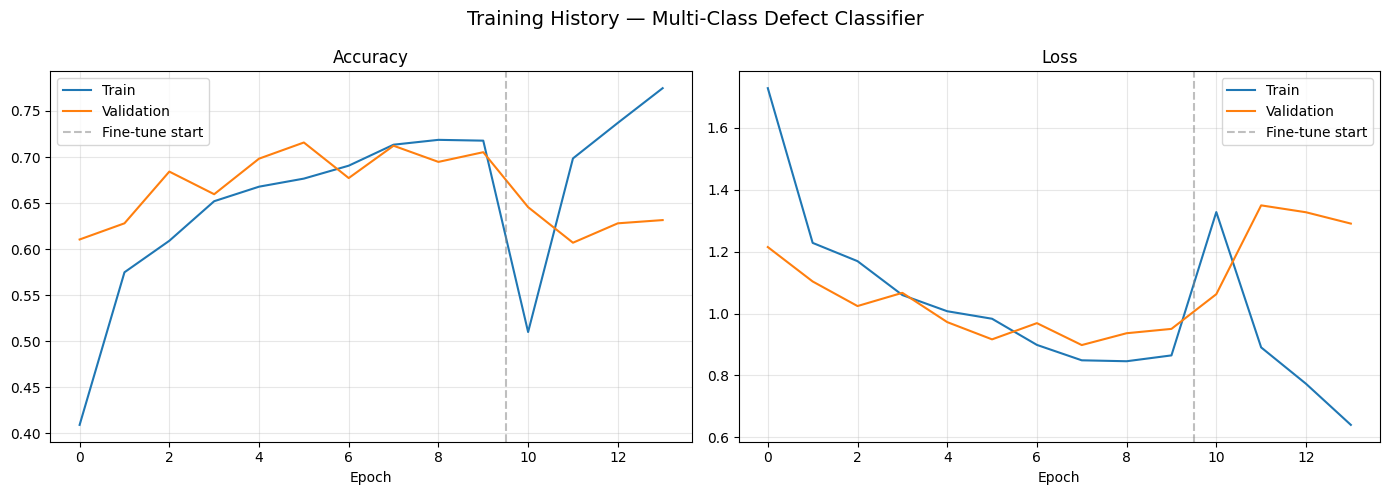

In [14]:
# Combine and plot training history
history = {
    'accuracy':     history_phase1.history['accuracy']     + history_phase2.history['accuracy'],
    'val_accuracy': history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy'],
    'loss':         history_phase1.history['loss']         + history_phase2.history['loss'],
    'val_loss':     history_phase1.history['val_loss']     + history_phase2.history['val_loss'],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['accuracy'], label='Train')
axes[0].plot(history['val_accuracy'], label='Validation')
axes[0].axvline(x=phase1_epochs - 0.5, color='gray', linestyle='--', alpha=0.5, label='Fine-tune start')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['loss'], label='Train')
axes[1].plot(history['val_loss'], label='Validation')
axes[1].axvline(x=phase1_epochs - 0.5, color='gray', linestyle='--', alpha=0.5, label='Fine-tune start')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History — Multi-Class Defect Classifier', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Evaluation

In [15]:
# Collect validation predictions
y_true = []
y_pred_probs = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Collected {len(y_true)} validation predictions")
print(f"\nClassification Report:")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

Collected 285 validation predictions

Classification Report:
                     precision    recall  f1-score   support

             blurry      0.292     0.412     0.341        17
              glare      0.462     0.621     0.529        29
               good      0.725     0.925     0.813        80
low_text_legibility      0.714     0.366     0.484        41
         obstructed      0.857     0.391     0.537        46
            qr_code      0.690     0.851     0.762        47
           too_dark      0.600     0.480     0.533        25

           accuracy                          0.646       285
          macro avg      0.620     0.578     0.571       285
       weighted avg      0.675     0.646     0.631       285



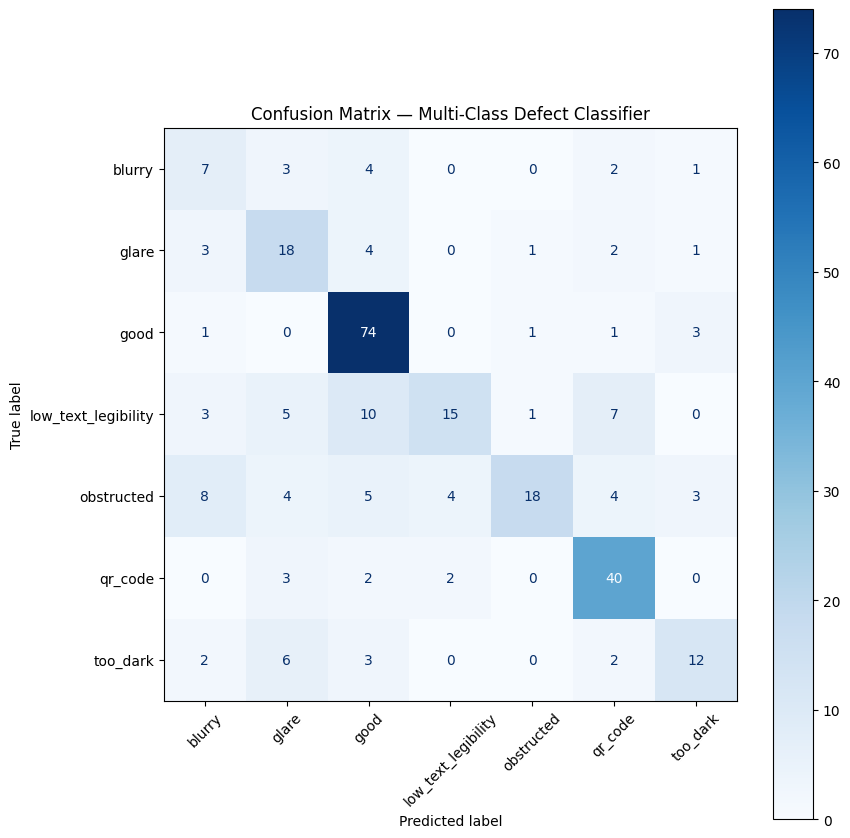


Overall accuracy: 64.6%

Per-class accuracy:
  blurry      : 41.2%  (17 samples)
  glare       : 62.1%  (29 samples)
  good        : 92.5%  (80 samples)
  low_text_legibility: 36.6%  (41 samples)
  obstructed  : 39.1%  (46 samples)
  qr_code     : 85.1%  (47 samples)
  too_dark    : 48.0%  (25 samples)


In [16]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=45)
plt.title('Confusion Matrix — Multi-Class Defect Classifier')
plt.tight_layout()
plt.show()

overall_acc = np.mean(y_pred == y_true)
print(f"\nOverall accuracy: {overall_acc:.1%}")
print(f"\nPer-class accuracy:")
for i, cls in enumerate(class_names):
    mask = y_true == i
    cls_acc = np.mean(y_pred[mask] == y_true[mask]) if mask.sum() > 0 else 0
    print(f"  {cls:<12}: {cls_acc:.1%}  ({mask.sum()} samples)")

In [17]:
# Confidence threshold analysis for 'good' class
# The 'good' class confidence score determines if a photo passes to OCR
good_idx = class_names.index('good')
good_scores = y_pred_probs[:, good_idx]

print("=== Good Class Confidence Threshold Analysis ===")
print("Threshold = minimum confidence to accept photo as 'good'\n")

for threshold in [0.5, 0.6, 0.7, 0.8]:
    accepted = good_scores >= threshold
    true_good = y_true == good_idx

    tp = np.sum(accepted & true_good)
    fp = np.sum(accepted & ~true_good)
    fn = np.sum(~accepted & true_good)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f"Threshold {threshold:.1f}: precision={precision:.3f}  recall={recall:.3f}  "
          f"accepted={accepted.sum()}  false_accepts={fp}")

print(f"\nRecommendation: Start at 0.6, tune based on real-world feedback")

=== Good Class Confidence Threshold Analysis ===
Threshold = minimum confidence to accept photo as 'good'

Threshold 0.5: precision=0.800  recall=0.900  accepted=90  false_accepts=18
Threshold 0.6: precision=0.852  recall=0.863  accepted=81  false_accepts=12
Threshold 0.7: precision=0.865  recall=0.800  accepted=74  false_accepts=10
Threshold 0.8: precision=0.889  recall=0.700  accepted=63  false_accepts=7

Recommendation: Start at 0.6, tune based on real-world feedback


## 8. Export Model

In [18]:
MODEL_NAME = 'photo_defect_classifier'
RECOMMENDED_THRESHOLD = 0.6

# Save .keras
keras_path = f'{MODEL_NAME}.keras'
model.save(keras_path)
keras_size = os.path.getsize(keras_path) / (1024 * 1024)
print(f"Saved: {keras_path} ({keras_size:.1f} MB)")

# Save weights
weights_path = f'{MODEL_NAME}.weights.h5'
model.save_weights(weights_path)
weights_size = os.path.getsize(weights_path) / (1024 * 1024)
print(f"Saved: {weights_path} ({weights_size:.1f} MB)")

# Convert to TFLite
print("\nConverting to TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = f'{MODEL_NAME}.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

tflite_size = os.path.getsize(tflite_path) / (1024 * 1024)
print(f"Saved: {tflite_path} ({tflite_size:.1f} MB)")
print(f"Size reduction: {keras_size / tflite_size:.1f}x smaller than .keras")

Saved: photo_defect_classifier.keras (25.3 MB)
Saved: photo_defect_classifier.weights.h5 (25.2 MB)

Converting to TFLite...
Saved artifact at '/tmp/tmpw50yhq6s'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  136704111955024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111956944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111957904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111957520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111956752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111957712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111957328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111959056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111958672: TensorSpe

In [19]:
MODEL_NAME = 'qc_multiclass'
RECOMMENDED_THRESHOLD = 0.6

# Save .keras
keras_path = f'{MODEL_NAME}.keras'
model.save(keras_path)
keras_size = os.path.getsize(keras_path) / (1024 * 1024)
print(f"Saved: {keras_path} ({keras_size:.1f} MB)")

# Save weights
weights_path = f'{MODEL_NAME}.weights.h5'
model.save_weights(weights_path)
weights_size = os.path.getsize(weights_path) / (1024 * 1024)
print(f"Saved: {weights_path} ({weights_size:.1f} MB)")

# Convert to TFLite
print("\nConverting to TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = f'{MODEL_NAME}.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

tflite_size = os.path.getsize(tflite_path) / (1024 * 1024)
print(f"Saved: {tflite_path} ({tflite_size:.1f} MB)")
print(f"Size reduction: {keras_size / tflite_size:.1f}x smaller than .keras")

# Save metadata
metadata = {
    'model_name': MODEL_NAME,
    'model_version': '1.0',
    'model_type': 'multi_class',
    'input_size': IMG_SIZE,
    'num_classes': NUM_CLASSES,
    'class_names': class_names,
    'recommended_threshold': RECOMMENDED_THRESHOLD,
    'output_interpretation': {
        'description': f'Softmax probabilities for {NUM_CLASSES} classes',
        'class_order': class_names,
        'good_class_index': good_idx,
        'prediction': 'argmax of output = predicted class',
        'pass_condition': f'output[{good_idx}] >= {RECOMMENDED_THRESHOLD} (good class confidence)',
    },
    'messages': {
        'good':                None,
        'blurry':              'Text is not sharp enough to read. Hold steady and pause briefly before taking the photo.',
        'too_dark':            'Label is too dark to read clearly. Use flash if needed and keep the camera straight to the label.',
        'glare':               'Flash reflection is covering part of the text. Slightly adjust your position to reduce glare.',
        'low_text_legibility': 'Label appears faded or damaged — do your best to capture it clearly.',
        'qr_code':             'Capture the full data label with serial and model numbers visible.',
        'obstructed':          'Something is blocking the label — move the obstruction and retake the photo.',
    },
    'validation_accuracy': float(overall_acc),
    'training_date': '2026-02-25',
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved: model_metadata.json")
print(json.dumps(metadata, indent=2))

Saved: qc_multiclass.keras (25.3 MB)
Saved: qc_multiclass.weights.h5 (25.2 MB)

Converting to TFLite...
Saved artifact at '/tmp/tmppj55ub_n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  136704111955024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111956944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111957904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111957520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111956752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111957712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111957328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111959056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136704111958672: TensorSpec(shape=(), dtype=tf

In [20]:
# Download all files
from google.colab import files

print("Downloading model files...")
files.download(keras_path)
files.download(weights_path)
files.download(tflite_path)
files.download('model_metadata.json')
print("Done!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


## 9. Quick Inference Test

In [21]:
def predict_photo(image_path, model, class_names, threshold=0.6, img_size=224):
    """Predict defect class for a photo.

    Returns:
        dict with predicted class, confidence scores, pass/fail, and message
    """
    img = keras.utils.load_img(image_path, target_size=(img_size, img_size))
    img_array = keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    probs = model.predict(img_array, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    good_idx = class_names.index('good')

    messages = {
        'good':                None,
        'blurry':              'Text is not sharp enough to read. Hold steady and pause briefly before taking the photo.',
        'too_dark':            'Label is too dark to read clearly. Use flash if needed and keep the camera straight to the label.',
        'glare':               'Flash reflection is covering part of the text. Slightly adjust your position to reduce glare.',
        'low_text_legibility': 'Label appears faded or damaged — do your best to capture it clearly.',
        'qr_code':             'Capture the full data label with serial and model numbers visible.',
        'obstructed':          'Something is blocking the label — move the obstruction and retake the photo.',
    }

    return {
        'predicted_class': pred_class,
        'passed': probs[good_idx] >= threshold,
        'good_confidence': float(probs[good_idx]),
        'all_scores': {cls: float(probs[i]) for i, cls in enumerate(class_names)},
        'message': messages.get(pred_class),
    }

# Test on sample images
import random
print("=== Sample Predictions ===")
for cls in class_names:
    cls_dir = os.path.join(DATA_DIR, cls)
    if os.path.exists(cls_dir) and os.listdir(cls_dir):
        sample = random.choice(os.listdir(cls_dir))
        result = predict_photo(os.path.join(cls_dir, sample), model, class_names)
        status = 'PASS' if result['passed'] else 'FAIL'
        print(f"\n[{status}] {cls}/{sample}")
        print(f"  Predicted: {result['predicted_class']}  (good confidence: {result['good_confidence']:.3f})")
        if result['message']:
            print(f"  Message: {result['message']}")
        print(f"  All scores: { {k: f'{v:.3f}' for k,v in result['all_scores'].items()} }")

=== Sample Predictions ===

[PASS] blurry/unit_181117.jpg
  Predicted: good  (good confidence: 0.864)
  All scores: {'blurry': '0.111', 'glare': '0.009', 'good': '0.864', 'low_text_legibility': '0.000', 'obstructed': '0.005', 'qr_code': '0.000', 'too_dark': '0.010'}

[FAIL] glare/unit_164795.jpg
  Predicted: glare  (good confidence: 0.000)
  Message: Flash reflection is covering part of the text. Slightly adjust your position to reduce glare.
  All scores: {'blurry': '0.000', 'glare': '0.991', 'good': '0.000', 'low_text_legibility': '0.009', 'obstructed': '0.000', 'qr_code': '0.001', 'too_dark': '0.000'}

[FAIL] good/unit_181889 - Copy.jpg
  Predicted: too_dark  (good confidence: 0.011)
  Message: Label is too dark to read clearly. Use flash if needed and keep the camera straight to the label.
  All scores: {'blurry': '0.015', 'glare': '0.152', 'good': '0.011', 'low_text_legibility': '0.000', 'obstructed': '0.000', 'qr_code': '0.000', 'too_dark': '0.822'}

[FAIL] low_text_legibility/un

---
## Next Steps

1. **Drop model files into your pipeline:**
   ```
   ml_training_photos/
     Gatekeeper_V1/
       photo_defect_classifier.tflite
       model_metadata.json
   ```

2. **Register in `gatekeeper_loader.py`:**
   ```python
   GATEKEEPER_VARIANTS = {
       '0.5': ...,          # binary — existing
       'v1':  ...,          # multi-class — new
   }
   ```

3. **Response now includes WHY the photo failed:**
   ```json
   {
     "gk_passed": false,
     "gk_reason": "blurry",
     "gk_message": "Photo is blurry — hold steady and tap to focus.",
     "gk_scores": { "good": 0.03, "blurry": 0.81, "too_dark": 0.06, "glare": 0.05, "cropped": 0.05 }
   }
   ```

4. **YOLO label detector** — next model to train once multi-class is validated